# Import Libraries

In [2]:
import os
from pathlib import Path

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# Dataset Paths

In [3]:
TRAIN_DIR = Path("../data/raw/Training")
TEST_DIR = Path("../data/raw/Testing")

# Define Image Size

In [4]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

# Training Transform

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Test Transform

In [6]:
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create Dataset

In [7]:
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

# Class Mapping

In [8]:
class_names = train_dataset.classes

print(class_names)

print(train_dataset.class_to_idx)

['glioma', 'meningioma', 'notumor', 'pituitary']
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


# Create DataLoaders

In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

# Verify DataLoader

In [10]:
images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

Images Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])


# Visualizing Preprocessed Images

In [11]:
# Function to reverse normalization
def denormalize(image):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    image = image * std + mean
    image = image.clamp(0,1)

    return image

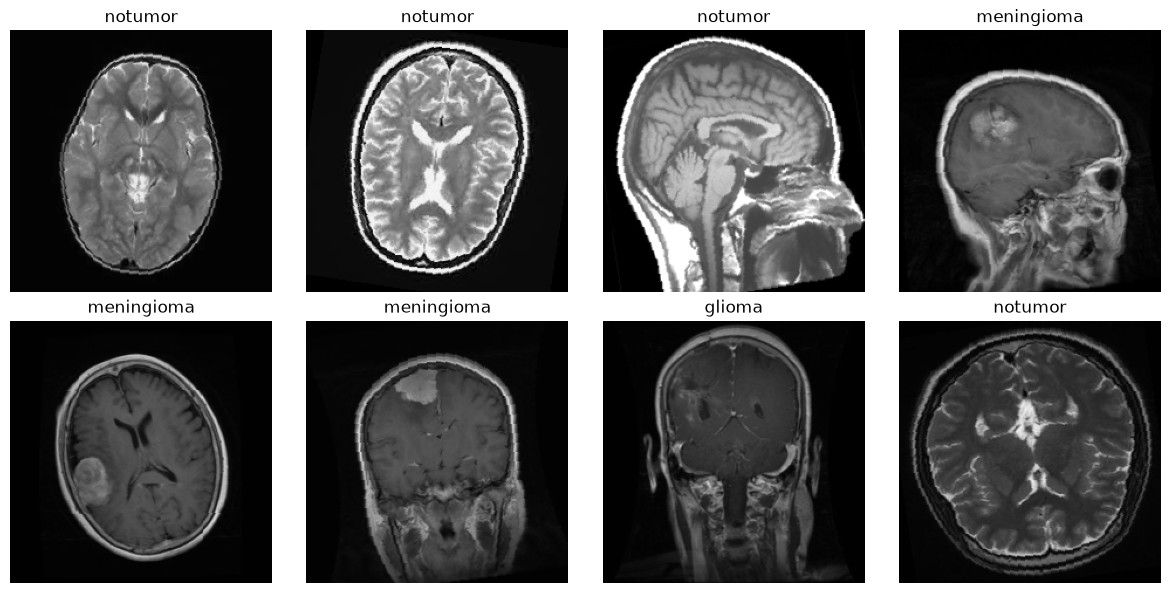

In [12]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12,6))

for i, ax in enumerate(axes.flat):

    img = denormalize(images[i])

    ax.imshow(img.permute(1,2,0))
    ax.set_title(class_names[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Dataset Information

In [13]:
print("="*50)
print("Dataset Information")
print("="*50)

print(f"Training Images : {len(train_dataset)}")
print(f"Testing Images  : {len(test_dataset)}")
print(f"Classes         : {class_names}")
print(f"Number of Classes : {len(class_names)}")

Dataset Information
Training Images : 5600
Testing Images  : 1600
Classes         : ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of Classes : 4


# Batch Information

In [14]:
print("="*50)
print("Batch Information")
print("="*50)

print(f"Batch Size : {BATCH_SIZE}")

print(f"Training Batches : {len(train_loader)}")
print(f"Testing Batches  : {len(test_loader)}")

Batch Information
Batch Size : 32
Training Batches : 175
Testing Batches  : 50


# Save Class Mapping

In [15]:
import json

class_mapping = train_dataset.class_to_idx

with open("../models/class_mapping.json", "w") as f:
    json.dump(class_mapping, f, indent=4)

print("Class mapping saved successfully.")

Class mapping saved successfully.


# Verify Tensor Shapes

In [16]:
images, labels = next(iter(train_loader))

print("Image Tensor Shape :", images.shape)
print("Label Tensor Shape :", labels.shape)

print("Data Type :", images.dtype)
print("Device :", images.device)

Image Tensor Shape : torch.Size([32, 3, 224, 224])
Label Tensor Shape : torch.Size([32])
Data Type : torch.float32
Device : cpu


#  Preprocessing Summary

In [17]:
print("="*60)
print("Data Preprocessing Completed")
print("="*60)

print(f"Image Size      : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Training Images : {len(train_dataset)}")
print(f"Testing Images  : {len(test_dataset)}")
print(f"Classes         : {class_names}")

print("\nTransforms Applied:")
print("- Resize")
print("- Random Horizontal Flip")
print("- Random Rotation")
print("- Color Jitter")
print("- Normalize")

print("\nPreprocessing pipeline is ready for model training.")

Data Preprocessing Completed
Image Size      : 224 x 224
Batch Size      : 32
Training Images : 5600
Testing Images  : 1600
Classes         : ['glioma', 'meningioma', 'notumor', 'pituitary']

Transforms Applied:
- Resize
- Random Horizontal Flip
- Random Rotation
- Color Jitter
- Normalize

Preprocessing pipeline is ready for model training.
